In [ ]:
from tcc import import_macro_series, import_bitcoin_only, get_bitcoin_date_range
import warnings
warnings.filterwarnings('ignore')

# Ver período disponível
start, end = get_bitcoin_date_range()
print(f"Bitcoin disponível de {start} a {end}")

# Carregar dados para análise
data = import_macro_series(["vix", "creditSpreads", "fedFundsRate", 
                            'realGDP', 'treasury10Y2YSpread'])
print(data.head())


In [ ]:
# Filtrar dados para período entre 2017 e 2023
data_filtered = data[(data.index >= '2017-01-01') & (data.index <= '2023-12-31')]

# Criar coluna de log retornos do bitcoin
import numpy as np
data_filtered = data_filtered.copy()
data_filtered['bitcoin_log_returns'] = np.log(data_filtered['bitcoin'] / data_filtered['bitcoin'].shift(1))

# Remover primeira linha que terá NaN devido ao shift
data_filtered = data_filtered.dropna()

data_filtered



In [ ]:
# Normalização dos dados usando RobustScaler

from sklearn.preprocessing import RobustScaler
import pandas as pd
import joblib

# Criar uma cópia dos dados para normalização
data_normalized = data_filtered.copy()

# Inicializar o RobustScaler
scaler = RobustScaler()

# Remover NaN antes da normalização
data_clean = data_normalized.dropna()

# Aplicar normalização apenas nas colunas numéricas (excluindo NaN)
# O RobustScaler é robusto a outliers e usa mediana e IQR
data_normalized_values = scaler.fit_transform(data_clean)

# Criar DataFrame normalizado mantendo índices e colunas corretos
data_normalized = pd.DataFrame(
    data_normalized_values, 
    index=data_clean.index, 
    columns=data_clean.columns
)

# Salvar os parâmetros do scaler para uso posterior em dados de teste
joblib.dump(scaler, 'tcc_scaler_parameters.pkl')
print("Parâmetros do scaler salvos em 'scaler_parameters.pkl'")

# Também salvar informações sobre as colunas usadas no treinamento
scaler_info = {
    'columns': list(data_clean.columns),
    'feature_names': list(data_clean.columns),
    'n_features': len(data_clean.columns)
}
joblib.dump(scaler_info, 'tcc_scaler_info.pkl')

print("Dados originais (últimas 5 linhas):")
print(data_filtered.tail())
print("\nDados normalizados (últimas 5 linhas):")
print(data_normalized.tail())
print(f"\nShape dos dados normalizados: {data_normalized.shape}")
print(f"Colunas utilizadas no scaler: {scaler_info['columns']}")


In [ ]:
array = data_normalized.to_numpy()
array

In [ ]:
from ripser import Rips
import persim
import matplotlib.pyplot as plt

rips = Rips(maxdim=2)

w = 50
n = len(data_normalized)-(2*w)+1

wasserstein_distances = np.zeros((n,1))

for i in range(n):
    
    dgm1 = rips.fit_transform(array[i:i+w])
    dgm2 = rips.fit_transform(array[i+w+1:i+(2*w)+1])

    wasserstein_distances[i] = persim.wasserstein(dgm1[0], dgm2[0], matching=False)









In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criar subplots com plotly
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Preço do Bitcoin ao longo do tempo', 'Distância de Wasserstein ao longo do tempo'),
    vertical_spacing=0.1,
    shared_xaxes=True
)

# Subplot superior - Preços do Bitcoin
fig.add_trace(
    go.Scatter(
        x=data_filtered.index,
        y=data_filtered['bitcoin'],
        mode='lines',
        name='Bitcoin',
        line=dict(color='black', width=2.5)
    ),
    row=1, col=1
)

# Subplot inferior - Distâncias de Wasserstein
# Ajustar o índice para corresponder ao período das janelas deslizantes
start_idx = w
end_idx = start_idx + len(wasserstein_distances)
time_index = data_filtered.index[start_idx:end_idx]

fig.add_trace(
    go.Scatter(
        x=time_index,
        y=wasserstein_distances.flatten(),
        mode='lines',
        name='Distância de Wasserstein',
        line=dict(color='black', width=2.5, dash='dot')
    ),
    row=2, col=1
)

# Configurar layout
fig.update_layout(
    height=800,
    showlegend=False,
    title_text="",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black')
)

# Configurar eixos
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', linecolor='black')
fig.update_yaxes(title_text="Preço do Bitcoin", row=1, col=1, gridcolor='lightgray', linecolor='black')
fig.update_yaxes(title_text="Distância de Wasserstein", row=2, col=1, gridcolor='lightgray', linecolor='black')

fig.show()

## Plotagem Exemplo -- série temporal -> nuvens de pontos -> PDs 

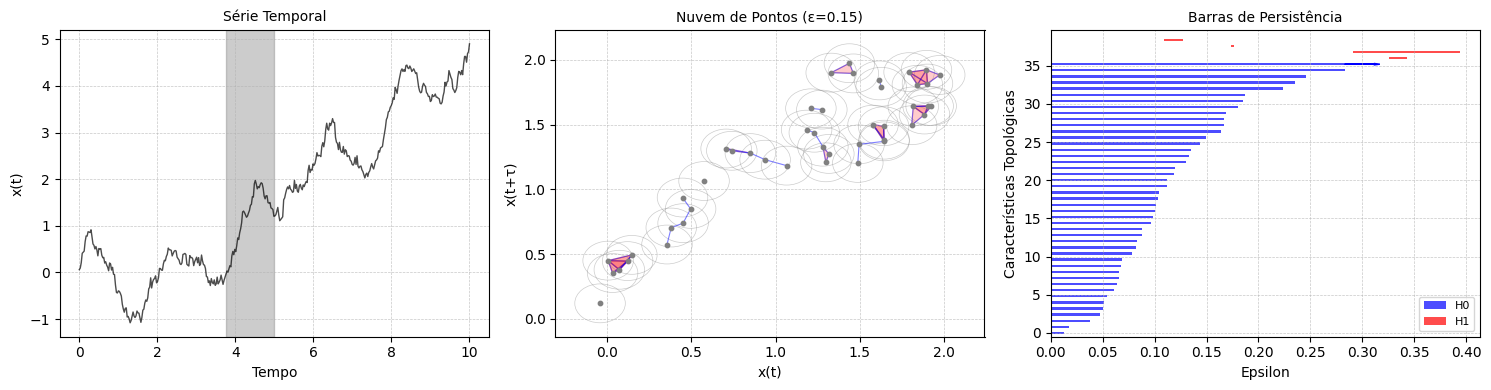

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

# Série temporal (seno composto)
np.random.seed(42)
t = np.linspace(0, 10, 400)
# Random walk with drift and sin component
drift = 0.01
volatility = 0.1
sin_amplitude = 0.5
sin_frequency = 0.5

# Generate random walk with drift
random_increments = np.random.normal(drift, volatility, len(t))
random_walk = np.cumsum(random_increments)

# Add sinusoidal component
x = random_walk + sin_amplitude * np.sin(2*np.pi*sin_frequency*t)

# Parâmetros do embedding
tau = 5
m = 2
window_length = 50  # Tamanho da janela
epsilon = 0.15  # Parâmetro para visualizar conexões entre pontos

# Selecionar uma janela específica (exemplo: janela no meio da série)
window_start = 150
window_end = window_start + window_length

# Extrair dados da janela selecionada
t_window = t[window_start:window_end]
x_window = x[window_start:window_end]

# Construção da nuvem de pontos (Embedding de Takens) para a janela
Q_window = len(x_window) - (m-1)*tau
points = np.array([x_window[i:i+(m*tau):tau] for i in range(Q_window)])

# Calcular diagramas de persistência
dgms = ripser(points, maxdim=1)['dgms']

# Criar figura lado a lado (1x3)
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# (a) Série temporal com janela sombreada
axs[0].plot(t, x, color='black', linewidth=1, alpha=0.7)
axs[0].axvspan(t[window_start], t[window_end-1], alpha=0.4, color='grey')
axs[0].set_title("Série Temporal", fontsize=10)
axs[0].set_xlabel("Tempo")
axs[0].set_ylabel("x(t)")
axs[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# (b) Nuvem de pontos (embedding) da janela selecionada com conexões
axs[1].scatter(points[:, 0], points[:, 1], s=10, color='grey', zorder=2)

# Adicionar círculos de raio epsilon ao redor de cada ponto
for point in points:
    circle = plt.Circle(point, epsilon, fill=False, color='grey', alpha=0.4, linewidth=0.5, zorder=1)
    axs[1].add_patch(circle)

# Adicionar conexões entre pontos próximos
for i in range(len(points)):
    for j in range(i+1, len(points)):
        dist = np.linalg.norm(points[i] - points[j])
        if dist <= epsilon:
            axs[1].plot([points[i, 0], points[j, 0]], [points[i, 1], points[j, 1]], 
                       'b-', alpha=0.5, linewidth=0.8, zorder=1)

# Identificar e colorir polígonos (ciclos) em vermelho
# Criar uma lista de adjacência baseada nas conexões
adjacency = {i: [] for i in range(len(points))}
for i in range(len(points)):
    for j in range(i+1, len(points)):
        dist = np.linalg.norm(points[i] - points[j])
        if dist <= epsilon:
            adjacency[i].append(j)
            adjacency[j].append(i)

# Encontrar ciclos simples (triângulos) e colori-los
for i in range(len(points)):
    for j in adjacency[i]:
        if j > i:  # Evitar duplicatas
            for k in adjacency[j]:
                if k > j and k in adjacency[i]:  # Triângulo encontrado
                    triangle_points = np.array([points[i], points[j], points[k]])
                    triangle = plt.Polygon(triangle_points, alpha=0.2, color='red', zorder=0)
                    axs[1].add_patch(triangle)

axs[1].set_title(f"Nuvem de Pontos (ε={epsilon})", fontsize=10)
axs[1].set_xlabel("x(t)")
axs[1].set_ylabel("x(t+τ)")
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# (c) Código de Barras de Persistência da janela
ax_barcode = axs[2]

# Plotar barras para H0 (componentes conectados)
h0_dgm = dgms[0]
h0_finite = h0_dgm[h0_dgm[:, 1] != np.inf]
h0_infinite = h0_dgm[h0_dgm[:, 1] == np.inf]

bar_height = 0.3  # Reduzir altura das barras para evitar sobreposição
y_offset = 0.8    # Espaçamento entre barras

# Barras finitas H0
for i, (birth, death) in enumerate(h0_finite):
    y_pos = i * y_offset
    ax_barcode.barh(y_pos, death - birth, left=birth, height=bar_height, 
                   color='blue', alpha=0.7, label='H0' if i == 0 else "")

# Barras infinitas H0
max_death = np.max(h0_finite[:, 1]) if len(h0_finite) > 0 else 1.0
for i, (birth, death) in enumerate(h0_infinite):
    y_pos = (len(h0_finite) + i) * y_offset
    ax_barcode.barh(y_pos, max_death - birth, left=birth, height=bar_height,
                   color='blue', alpha=0.7)
    # Adicionar seta para indicar infinito
    ax_barcode.arrow(max_death, y_pos, max_death * 0.1, 0,
                    head_width=0.2, head_length=max_death * 0.02, fc='blue', ec='blue')

# Plotar barras para H1 (buracos/ciclos)
if len(dgms) > 1:
    h1_dgm = dgms[1]
    h1_finite = h1_dgm[h1_dgm[:, 1] != np.inf]
    h1_infinite = h1_dgm[h1_dgm[:, 1] == np.inf]
    
    offset = len(h0_dgm) * y_offset
    
    # Barras finitas H1
    for i, (birth, death) in enumerate(h1_finite):
        y_pos = offset + i * y_offset
        ax_barcode.barh(y_pos, death - birth, left=birth, height=bar_height,
                       color='red', alpha=0.7, label='H1' if i == 0 else "")
    
    # Barras infinitas H1
    for i, (birth, death) in enumerate(h1_infinite):
        y_pos = offset + (len(h1_finite) + i) * y_offset
        ax_barcode.barh(y_pos, max_death - birth, left=birth, height=bar_height,
                       color='red', alpha=0.7)
        # Adicionar seta para indicar infinito
        ax_barcode.arrow(max_death, y_pos, max_death * 0.1, 0,
                        head_width=0.2, head_length=max_death * 0.02, fc='red', ec='red')

ax_barcode.set_title("Barras de Persistência", fontsize=10)
ax_barcode.set_xlabel("Epsilon")
ax_barcode.set_ylabel("Características Topológicas")
ax_barcode.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Ajustar limites do eixo y para evitar sobreposição com labels
total_bars = len(h0_dgm) + (len(dgms[1]) if len(dgms) > 1 else 0)
ax_barcode.set_ylim(-0.5, (total_bars) * y_offset + 0.5)

# Posicionar legenda no canto inferior direito
ax_barcode.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()



/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_3609/2943566902.py:161: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_barcode.legend(loc='upper right', fontsize=8)


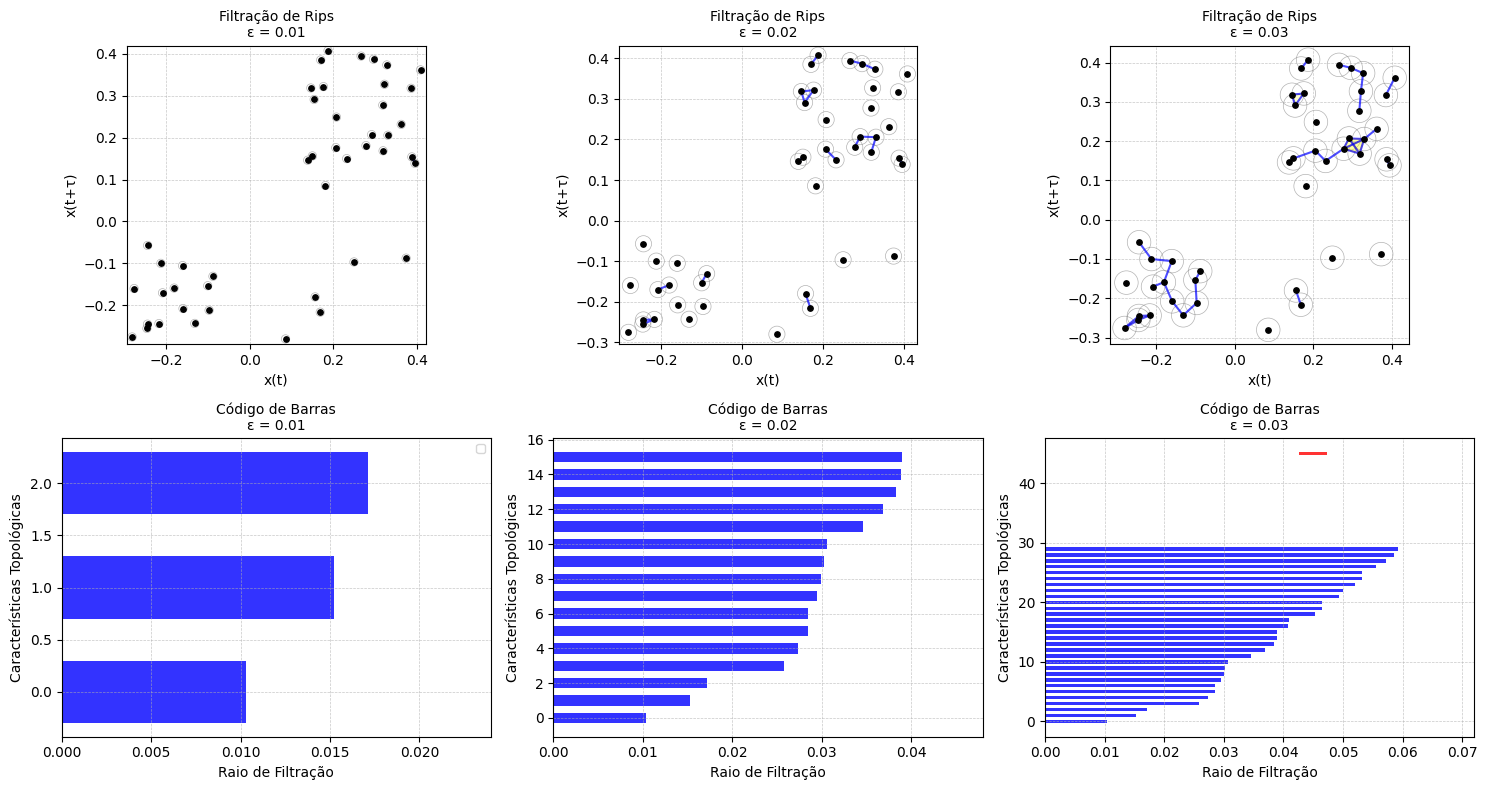


Análise da conectividade:
ε = 0.01: 3 arestas formadas
ε = 0.02: 18 arestas formadas
ε = 0.03: 36 arestas formadas


In [80]:
# Visualização do processo de filtração de Rips
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import Delaunay

def visualize_rips_filtration_with_barcodes(points, epsilon_values, title_prefix="Filtração de Rips"):
    """
    Visualiza o processo de filtração de Rips para diferentes valores de epsilon
    com destaque para buracos (ciclos) formados e códigos de barras correspondentes
    """
    n_eps = len(epsilon_values)
    fig, axs = plt.subplots(2, n_eps, figsize=(5*n_eps, 8))
    
    if n_eps == 1:
        axs = axs.reshape(2, 1)
    
    # Cores consistentes
    h0_color = 'blue'  # Componentes conectados
    h1_color = 'red'   # Buracos/ciclos
    
    for i, eps in enumerate(epsilon_values):
        # Subplot superior: Complexo simplicial
        ax_complex = axs[0, i]
        
        # Plotar pontos
        ax_complex.scatter(points[:, 0], points[:, 1], s=15, color='black', zorder=3)
        
        # Desenhar círculos ao redor de cada ponto
        for point in points:
            circle = patches.Circle(point, eps, fill=False, color='grey', alpha=0.6, linewidth=0.5)
            ax_complex.add_patch(circle)
        
        # Conectar pontos que estão dentro da distância epsilon
        edges = []
        connected_pairs = []
        for j in range(len(points)):
            for k in range(j+1, len(points)):
                dist = np.linalg.norm(points[j] - points[k])
                if dist <= 2*eps:  # Dois círculos se intersectam
                    edges.append([points[j], points[k]])
                    connected_pairs.append((j, k))
        
        if edges:
            line_collection = LineCollection(edges, colors=h0_color, alpha=0.7, linewidths=1.5)
            ax_complex.add_collection(line_collection)
        
        # Detectar e colorir buracos (ciclos) usando triangulação - apenas para epsilon maiores
        if len(connected_pairs) > 2 and eps >= 0.025:  # Só mostrar triângulos para epsilon >= 0.025
            # Criar matriz de adjacência
            n_points = len(points)
            adj_matrix = np.zeros((n_points, n_points))
            for j, k in connected_pairs:
                adj_matrix[j, k] = 1
                adj_matrix[k, j] = 1
            
            # Encontrar triângulos (ciclos de 3 pontos)
            triangles = []
            for j in range(n_points):
                for k in range(j+1, n_points):
                    for l in range(k+1, n_points):
                        if adj_matrix[j, k] and adj_matrix[k, l] and adj_matrix[l, j]:
                            triangles.append([j, k, l])
            
            # Colorir triângulos (representando buracos preenchidos)
            for triangle in triangles:
                triangle_points = points[triangle]
                polygon = Polygon(triangle_points, alpha=0.2, facecolor='yellow', 
                                edgecolor='orange', linewidth=1)
                ax_complex.add_patch(polygon)
            
            # Detectar ciclos de 4 pontos (quadriláteros) - apenas para epsilon ainda maiores
            if eps >= 0.03:
                quadrilaterals = []
                for j in range(n_points):
                    for k in range(j+1, n_points):
                        for l in range(k+1, n_points):
                            for m in range(l+1, n_points):
                                # Verificar se forma um ciclo de 4 pontos
                                if (adj_matrix[j, k] and adj_matrix[k, l] and 
                                    adj_matrix[l, m] and adj_matrix[m, j]):
                                    # Verificar se não é apenas um conjunto de triângulos
                                    if not (adj_matrix[j, l] and adj_matrix[k, m]):
                                        quadrilaterals.append([j, k, l, m])
                
                # Colorir quadriláteros (buracos mais evidentes)
                for quad in quadrilaterals:
                    quad_points = points[quad]
                    # Ordenar pontos para formar um polígono convexo
                    center = np.mean(quad_points, axis=0)
                    angles = np.arctan2(quad_points[:, 1] - center[1], 
                                      quad_points[:, 0] - center[0])
                    sorted_indices = np.argsort(angles)
                    sorted_quad_points = quad_points[sorted_indices]
                    
                    polygon = Polygon(sorted_quad_points, alpha=0.2, facecolor=h1_color, 
                                    edgecolor=h1_color, linewidth=2)
                    ax_complex.add_patch(polygon)
        
        ax_complex.set_title(f"{title_prefix}\nε = {eps:.2f}", fontsize=10)
        ax_complex.set_xlabel("x(t)")
        ax_complex.set_ylabel("x(t+τ)")
        ax_complex.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax_complex.set_aspect('equal')
        
        # Ajustar limites para mostrar os círculos
        margin = eps * 1.2
        x_min, x_max = points[:, 0].min() - margin, points[:, 0].max() + margin
        y_min, y_max = points[:, 1].min() - margin, points[:, 1].max() + margin
        ax_complex.set_xlim(x_min, x_max)
        ax_complex.set_ylim(y_min, y_max)
        
        # Subplot inferior: Código de barras
        ax_barcode = axs[1, i]
        
        # Calcular diagrama de persistência para este epsilon específico
        distances = squareform(pdist(points))
        dgms = ripser(points, maxdim=1, thresh=2*eps)['dgms']
        
        bar_height = 0.6  # Barras mais grossas
        
        # Plotar código de barras para H0 (componentes conectados)
        h0_plotted = False
        if len(dgms[0]) > 0:
            h0_bars = dgms[0]
            # Filtrar barras infinitas
            finite_h0 = h0_bars[h0_bars[:, 1] != np.inf]
            
            for j, (birth, death) in enumerate(finite_h0):
                ax_barcode.barh(j, death - birth, left=birth, height=bar_height, 
                               color=h0_color, alpha=0.8, 
                               )
                h0_plotted = True
        
        # Plotar código de barras para H1 (buracos/ciclos)
        h1_plotted = False
        if len(dgms) > 1 and len(dgms[1]) > 0:
            h1_bars = dgms[1]
            # Filtrar barras infinitas
            finite_h1 = h1_bars[h1_bars[:, 1] != np.inf]
            
            offset = len(dgms[0]) if len(dgms[0]) > 0 else 0
            for j, (birth, death) in enumerate(finite_h1):
                ax_barcode.barh(offset + j, death - birth, left=birth, height=bar_height, 
                               color=h1_color, alpha=0.8,
                               label='H₁' if not h1_plotted else "")
                h1_plotted = True
        
        ax_barcode.set_title(f"Código de Barras\nε = {eps:.2f}", fontsize=10)
        ax_barcode.set_xlabel("Raio de Filtração")
        ax_barcode.set_ylabel("Características Topológicas")
        ax_barcode.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        
        # Configurar limites
        ax_barcode.set_xlim(0, 2*eps * 1.2)
        
        # Adicionar legenda apenas no primeiro subplot
        if i == 0:
            ax_barcode.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Definir diferentes valores de epsilon para mostrar a evolução da filtração
epsilon_values = [0.01, 0.02, 0.03]



visualize_rips_filtration_with_barcodes(points, epsilon_values)

# Análise adicional: mostrar como o número de componentes conectados muda
print("\nAnálise da conectividade:")
for eps in epsilon_values:
    # Contar componentes conectados
    n_edges = 0
    for j in range(len(points)):
        for k in range(j+1, len(points)):
            dist = np.linalg.norm(points[j] - points[k])
            if dist <= 2*eps:
                n_edges += 1
    
    print(f"ε = {eps:.2f}: {n_edges} arestas formadas")
